# 03 — PSI comparison: Strict vs Variable 1nt

**Question:** For events detected in BOTH modes, does relaxing the boundary by 1nt change the quantification (PSI)?

**Why:** Notebook 01 told us which events are new in variable. Now we ask, for the events both modes share, whether the PSI value shifts. This is measured by delta PSI per event.

delta PSI = | PSI_strict(event) - PSI_variable(event) |

**Key point:** delta PSI must be computed event by event, because PSI is a property of one specific splice event. To pair the same event across modes we reuse the coordinate reformatting from notebook 01 (strict and variable PSI files inherit the IOE coordinate formats).

**Samples:** KM1-KM3 = CT8 | KM4-KM6 = CT20 | KM7-KM9 = PerKO

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
muted = sns.color_palette("muted")

BASE = "/Users/gricey/Desktop/Internship/data"
EVENT_TYPES = ["A3", "A5", "RI"]

SAMPLES = ["KM1","KM2","KM3","KM4","KM5","KM6","KM7","KM8","KM9"]
CONDITIONS = {
    "CT8":   ["KM1","KM2","KM3"],
    "CT20":  ["KM4","KM5","KM6"],
    "PerKO": ["KM7","KM8","KM9"],
}

print("Libraries loaded!")

Libraries loaded!


In [68]:
# --- Table helpers (same style as other notebooks) ---

def style_table(df, caption=""):
    styled = df.style\
        .set_properties(**{
            "font-size": "12px", "font-weight": "bold",
            "border": "1px solid #ddd", "padding": "6px 12px",
            "text-align": "center"
        })\
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#2196F3"), ("color", "white"),
                ("font-weight", "bold"), ("padding", "6px 12px"),
                ("text-align", "center")]},
            {"selector": "tr:nth-child(even)", "props": [
                ("background-color", "#f2f2f2")]},
        ])\
        .hide(axis="index")
    if caption:
        styled = styled.set_caption(caption)
    return styled


def export_table_png(df, filepath, title="", figsize=None):
    if figsize is None:
        figsize = (len(df.columns) * 2.2, len(df) * 0.6 + 0.8)
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    table = ax.table(cellText=df.values, colLabels=df.columns,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2196F3")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")
        cell.set_edgecolor("#dddddd")
    if title:
        ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved -> {filepath}")

print("Helpers loaded!")

Helpers loaded!


## Coordinate reformatting (same as notebook 01)

Translates strict event IDs into variable format so the same event has the same ID in both PSI files. Strand aware for A3 and A5.

In [69]:
def reformat_strict_event_id(event_id, event_type):
    try:
        gene_part, rest = event_id.split(";")
        tokens = rest.split(":")
        etype  = tokens[0]; chrom = tokens[1]; strand = tokens[-1]
        coords = tokens[2:-1]
        if event_type == "RI":
            inner = [c for c in coords if "-" in c]
            if len(inner) != 1: return None
            return f"{gene_part};{etype}:{chrom}:{inner[0]}:{strand}"
        elif event_type == "A3":
            if len(coords) != 2: return None
            if strand == "+":
                c1, c2 = coords[0].split("-")[1], coords[1].split("-")[1]
            else:
                c1, c2 = coords[0].split("-")[0], coords[1].split("-")[0]
            return f"{gene_part};{etype}:{chrom}:{c1}:{c2}:{strand}"
        elif event_type == "A5":
            if len(coords) != 2: return None
            if strand == "+":
                c1, c2 = coords[0].split("-")[0], coords[1].split("-")[0]
            else:
                c1, c2 = coords[0].split("-")[1], coords[1].split("-")[1]
            return f"{gene_part};{etype}:{chrom}:{c1}:{c2}:{strand}"
    except Exception:
        return None

print("Reformatting function ready!")

Reformatting function ready!


## Step 1 — Load PSI files

Load strict and variable PSI files. Each row is one event, each column one sample.
We drop the duplicate header rows that variable mode sometimes writes, and coerce
all PSI values to numeric (so 'nan' strings become real NaN).

In [70]:
def load_psi(path):
    df = pd.read_csv(path, sep="\t", index_col=0)
    df = df[~df.index.astype(str).str.startswith("KM")]   # drop repeated headers
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

psi = {}
for event in EVENT_TYPES:
    psi[("strict", event)] = load_psi(f"{BASE}/output_strict/psi/{event}.psi")
    psi[("var1",   event)] = load_psi(f"{BASE}/output_variable_1nt/psi/{event}.psi")
    print(f"{event}: strict={len(psi[('strict', event)])} events, "
          f"var1={len(psi[('var1', event)])} events")

A3: strict=11163 events, var1=22931 events
A5: strict=9629 events, var1=19455 events
RI: strict=5315 events, var1=17336 events


## Step 1b — Raw PSI distributions for shared genes (exploratory)

Before computing delta PSI, we visualise how PSI values are distributed
across strict vs variable for genes detected in both modes.
This shows that variable mode consistently pulls the median PSI down,
motivating the event-level delta PSI analysis in Step 2.

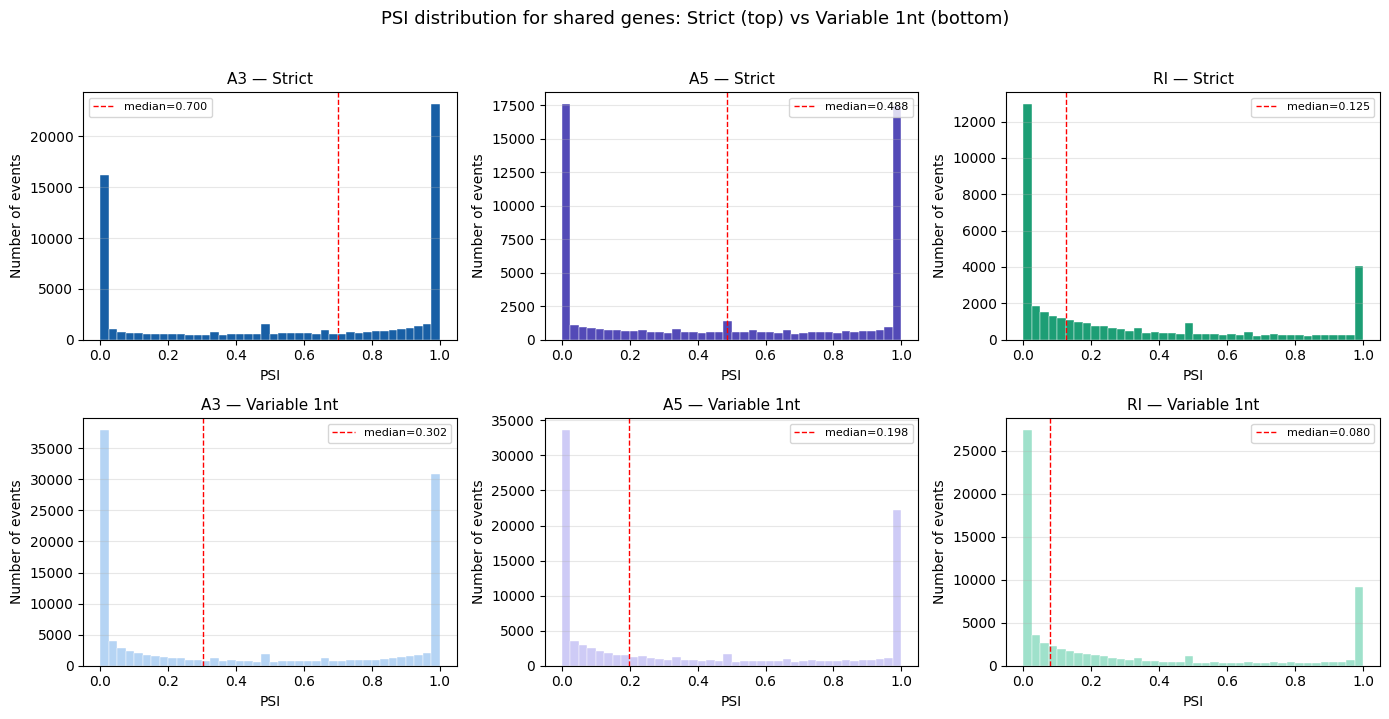

Saved!


In [71]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

hist_colors = {
    "A3": {"strict": "#185FA5", "var1": "#B5D4F4"},
    "A5": {"strict": "#534AB7", "var1": "#CECBF6"},
    "RI": {"strict": "#1D9E75", "var1": "#9FE1CB"},
}

for i, event in enumerate(EVENT_TYPES):
    strict_df = psi[("strict", event)]
    var1_df   = psi[("var1",   event)]

    # Get shared genes (based on index format "ENSMUSG...;...")
    strict_genes = set(idx.split(";")[0] for idx in strict_df.index
                       if idx.startswith("ENSMUSG"))
    var1_genes   = set(idx.split(";")[0] for idx in var1_df.index
                       if idx.startswith("ENSMUSG"))
    shared_genes = strict_genes & var1_genes

    strict_vals = strict_df[
        strict_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
        .isin(shared_genes)
    ].values.flatten()
    strict_vals = strict_vals[~np.isnan(strict_vals)]

    var1_vals = var1_df[
        var1_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
        .isin(shared_genes)
    ].values.flatten()
    var1_vals = var1_vals[~np.isnan(var1_vals)]

    # Top row: strict
    ax_top = axes[0, i]
    ax_top.hist(strict_vals, bins=40, color=hist_colors[event]["strict"], edgecolor="white", linewidth=0.3)
    ax_top.set_title(f"{event} — Strict", fontsize=11)
    ax_top.set_ylabel("Number of events")
    ax_top.set_xlabel("PSI")
    ax_top.axvline(np.median(strict_vals), color="red", linestyle="--",
                   linewidth=1, label=f"median={np.median(strict_vals):.3f}")
    ax_top.legend(fontsize=8)
    ax_top.grid(axis="y", alpha=0.3)

    # Bottom row: variable
    ax_bot = axes[1, i]
    ax_bot.hist(var1_vals, bins=40, color=hist_colors[event]["var1"], edgecolor="white", linewidth=0.3)
    ax_bot.set_title(f"{event} — Variable 1nt", fontsize=11)
    ax_bot.set_ylabel("Number of events")
    ax_bot.set_xlabel("PSI")
    ax_bot.axvline(np.median(var1_vals), color="red", linestyle="--",
                   linewidth=1, label=f"median={np.median(var1_vals):.3f}")
    ax_bot.legend(fontsize=8)
    ax_bot.grid(axis="y", alpha=0.3)

plt.suptitle("PSI distribution for shared genes: Strict (top) vs Variable 1nt (bottom)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/hist_psi_shared_genes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## Step 2 — Match shared events and compute delta PSI

For each event type:
1. Reformat strict event IDs into variable format
2. Keep only events present in BOTH modes (shared)
3. For each shared event, compute delta PSI per sample: |PSI_strict - PSI_variable|

delta PSI is the magnitude of the quantification shift caused by relaxing the boundary.

In [72]:
dpsi_data = {}   # stores per-event-type delta PSI dataframes

for event in EVENT_TYPES:
    strict_df = psi[("strict", event)].copy()
    var1_df   = psi[("var1",   event)]

    # Reformat strict index to variable format
    strict_df.index = [reformat_strict_event_id(e, event) for e in strict_df.index]
    strict_df = strict_df[strict_df.index.notna()]

    # Shared event IDs (present in both modes)
    shared_ids = strict_df.index.intersection(var1_df.index)

    # Align both dataframes on shared events, same sample columns
    strict_shared = strict_df.loc[shared_ids, SAMPLES]
    var1_shared   = var1_df.loc[shared_ids, SAMPLES]

    # delta PSI per sample (absolute)
    dpsi = (strict_shared - var1_shared).abs()

    dpsi_data[event] = {
        "strict": strict_shared,
        "var1":   var1_shared,
        "dpsi":   dpsi,
    }
    print(f"{event}: {len(shared_ids)} shared events matched")

A3: 10750 shared events matched
A5: 9251 shared events matched
RI: 5073 shared events matched


## Step 3 — Density plot of delta PSI (filter 0 < PSI < 1)

**Why filter:** PSI = 0 means the event is never used, PSI = 1 means it is always included (constitutive). Neither is alternative splicing, so they add noise. We keep only events whose PSI is strictly between 0 and 1 in the strict mode (genuinely alternative events).

**The plot:** density (KDE) of delta PSI across all shared, expressed events.
- one peak near 0 means strict and variable agree (PSI barely changes)
- a second peak away from 0 means a population of events where the modes disagree

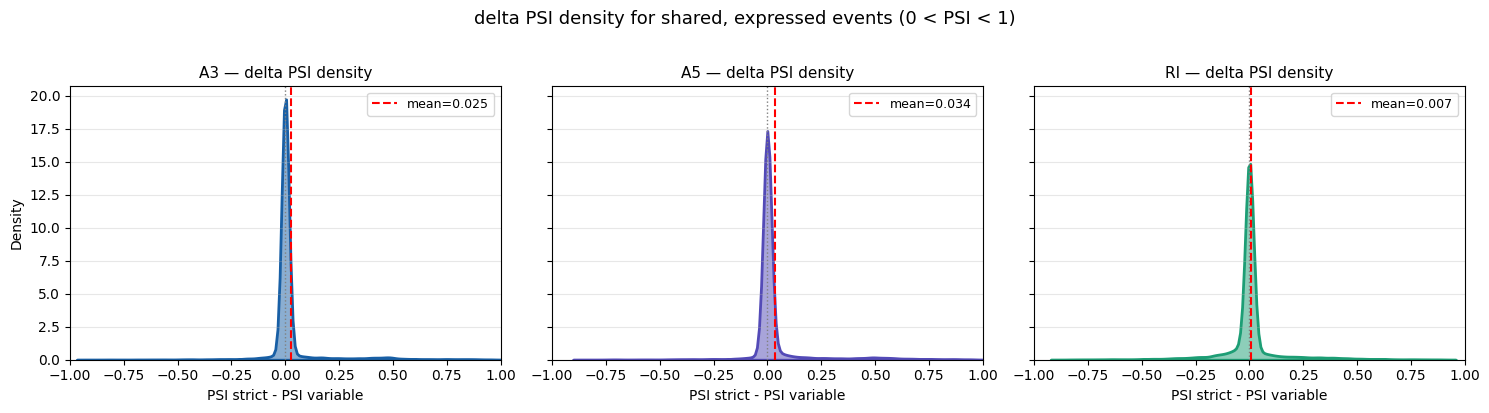

Saved!


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ["#185FA5", "#534AB7", "#1D9E75"]  # A3 blue, A5 purple, RI green

for i, event in enumerate(EVENT_TYPES):
    strict_shared = dpsi_data[event]["strict"]
    var1_shared   = dpsi_data[event]["var1"]

    # Drop duplicate indices (keep first occurrence)
    strict_dedup = strict_shared[~strict_shared.index.duplicated(keep="first")]
    var1_dedup   = var1_shared[~var1_shared.index.duplicated(keep="first")]

    # Common events after dedup
    common = strict_dedup.index.intersection(var1_dedup.index)
    s = strict_dedup.loc[common].values.flatten()
    v = var1_dedup.loc[common].values.flatten()

    dpsi_signed = s - v

    keep = (s > 0) & (s < 1) & (~np.isnan(dpsi_signed))
    dpsi_kept = dpsi_signed[keep]

    ax = axes[i]
    sns.kdeplot(dpsi_kept, ax=ax, fill=True, color=colors[i],
                alpha=0.5, linewidth=2)
    ax.set_title(f"{event} — delta PSI density", fontsize=11)
    ax.set_xlabel("PSI strict - PSI variable")
    ax.set_ylabel("Density")
    ax.set_xlim(-1, 1)
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    ax.grid(axis="y", alpha=0.3)

    # median_val = np.median(dpsi_kept)
    # ax.axvline(median_val, color="red", linestyle="--", linewidth=1.5,
    #        label=f"median={median_val:.3f}")
    # ax.legend(fontsize=9)
    # mean is better because it captures the overall shift, while median is often zero due to many events having no change
    mean_val = np.mean(dpsi_kept)
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5,
               label=f"mean={mean_val:.3f}")
    ax.legend(fontsize=9)

    # Show number of events in top-right corner
    # ax.text(0.95, 0.85, f"n={len(dpsi_kept):,}",
    #        transform=ax.transAxes, ha="right", fontsize=9,
    #        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("delta PSI density for shared, expressed events (0 < PSI < 1)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/density_dpsi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## Step 4 — Significant splicing events: WT CT20 vs PerKO CT20

Load diffSplice output (temp.1) for strict and variable 1nt.
Filter to |dPSI| > 0.1 and p < 0.05.
Compare how many significant events each mode detects.

In [74]:
import os

DIFF_STRICT = "/Users/gricey/Desktop/Internship/data/output_strict/diff"
DIFF_VAR1   = "/Users/gricey/Desktop/Internship/data/output_variable_1nt/diff"

DPSI_THRESH = 0.1
PVAL_THRESH = 0.05

def load_dpsi(path):
    df = pd.read_csv(path, sep="\t", header=0)
    df.columns = ["event_id", "dPSI", "p_value"]
    df = df.dropna()
    df = df[df["p_value"] != "nan"]
    df["dPSI"]    = pd.to_numeric(df["dPSI"],    errors="coerce")
    df["p_value"] = pd.to_numeric(df["p_value"], errors="coerce")
    df = df.dropna()
    return df

def filter_significant(df):
    return df[(df["dPSI"].abs() > DPSI_THRESH) & (df["p_value"] < PVAL_THRESH)]

rows = []
sig_events = {}  # store event ID sets for Venn later

# reuse the same reformatting function from earlier in this notebook
def get_shared_sig(ids_strict_raw, ids_var1, event):
    ids_strict_fmt = set()
    for eid in ids_strict_raw:
        reformatted = reformat_strict_event_id(eid, event)
        if reformatted:
            ids_strict_fmt.add(reformatted)
    shared   = ids_strict_fmt & ids_var1
    var_only = ids_var1 - ids_strict_fmt
    return ids_strict_fmt, shared, var_only

for event in EVENT_TYPES:
    path_strict = os.path.join(DIFF_STRICT, f"diff_{event}.dpsi.temp.1")
    path_var1   = os.path.join(DIFF_VAR1,   f"diff_{event}.dpsi.temp.1")

    df_strict = load_dpsi(path_strict)
    df_var1   = load_dpsi(path_var1)

    sig_strict = filter_significant(df_strict)
    sig_var1   = filter_significant(df_var1)

    ids_strict_raw = set(sig_strict["event_id"])
    ids_var1       = set(sig_var1["event_id"])
    ids_strict_fmt, ids_shared, ids_var_only = get_shared_sig(ids_strict_raw, ids_var1, event)
    
    sig_events[event] = {
        "strict":   ids_strict,
        "var1":     ids_var1,
        "shared":   ids_shared,
        "var_only": ids_var_only,
    }

    rows.append({
        "Event":              event,
        "sig strict":         len(ids_strict),
        "sig variable":       len(ids_var1),
        "shared sig":         len(ids_shared),
        "only in variable":   len(ids_var_only),
    })

df_sig = pd.DataFrame(rows)
display(style_table(df_sig, "Significant events: WT CT20 vs PerKO CT20 (|dPSI| > 0.1, p < 0.05)"))
export_table_png(
    df_sig,
    "../../figures/plots/table_sig_events_CT20_PerKO.png",
    title="Significant events: WT CT20 vs PerKO CT20 (|dPSI| > 0.1, p < 0.05)",
    figsize=(14, 3)
)

Event,sig strict,sig variable,shared sig,only in variable
A3,47,73,25,48
A5,47,76,30,46
RI,47,64,9,55


Saved -> ../../figures/plots/table_sig_events_CT20_PerKO.png


## Step 4b — Significant events: concentric circles

Same subset logic as the event population circles, but now filtered to
biologically significant events only (|dPSI| > 0.1, p < 0.05, WT CT20 vs PerKO CT20).
Strict is a subset of variable even after filtering.

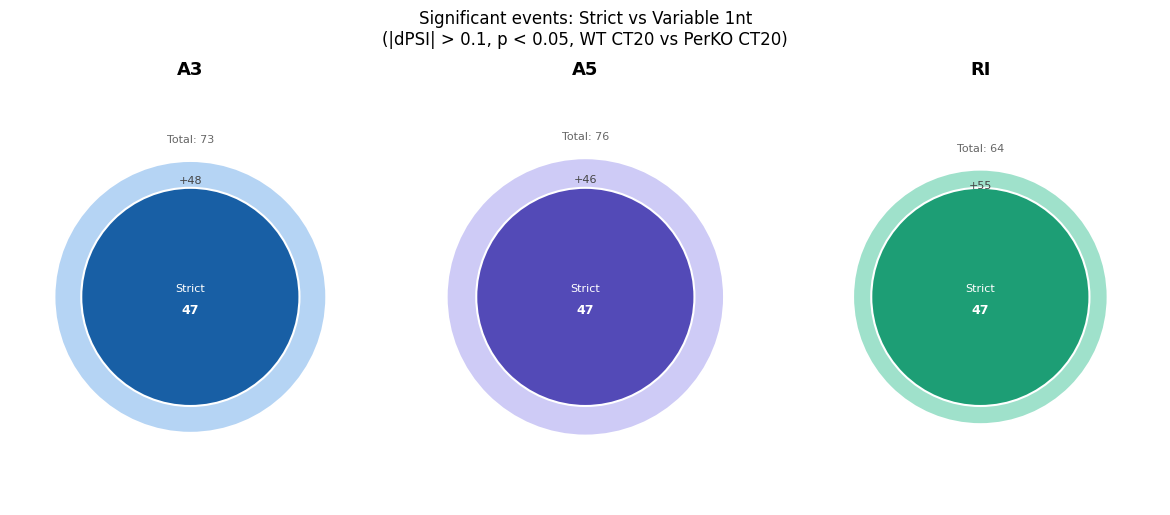

Saved!


In [84]:
# concentric circles significant events
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

colors = {
    "A3": {"outer": "#B5D4F4", "inner": "#185FA5"},
    "A5": {"outer": "#CECBF6", "inner": "#534AB7"},
    "RI": {"outer": "#9FE1CB", "inner": "#1D9E75"},
}

max_sig = max(len(sig_events[e]["var1"]) for e in EVENT_TYPES)

for i, event in enumerate(EVENT_TYPES):
    pop = sig_events[event]
    n_strict  = len(pop["strict"])
    n_var1    = len(pop["var1"])
    n_var_only = len(pop["var_only"])

    ax = axes[i]
    ax.set_aspect("equal")
    ax.axis("off")

    r_outer = np.sqrt(n_var1 / max_sig)
    r_inner = np.sqrt(n_strict / max_sig)

    outer = plt.Circle((0, 0), r_outer, color=colors[event]["outer"],
                        ec="white", linewidth=1.5)
    inner = plt.Circle((0, 0), r_inner, color=colors[event]["inner"],
                        ec="white", linewidth=1.5)

    ax.add_patch(outer)
    ax.add_patch(inner)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.5, 1.5)

    ax.text(0, 0.06, "Strict", ha="center", va="center",
            fontsize=8, color="white")
    ax.text(0, -0.1, f"{n_strict:,}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")

    ring_mid = (r_inner + r_outer) / 2
    ax.text(0, ring_mid - 0.05, f"+{n_var_only:,}", ha="center", va="center",
            fontsize=8, color="#444444")

    ax.text(0, r_outer + 0.15, f"Total: {n_var1:,}", ha="center", va="center",
            fontsize=8, color="#666666")

    ax.set_title(event, fontsize=13, fontweight="bold", pad=10)

plt.suptitle(
    "Significant events: Strict vs Variable 1nt\n(|dPSI| > 0.1, p < 0.05, WT CT20 vs PerKO CT20)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("../../figures/plots/venn_concentric_sig_events.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

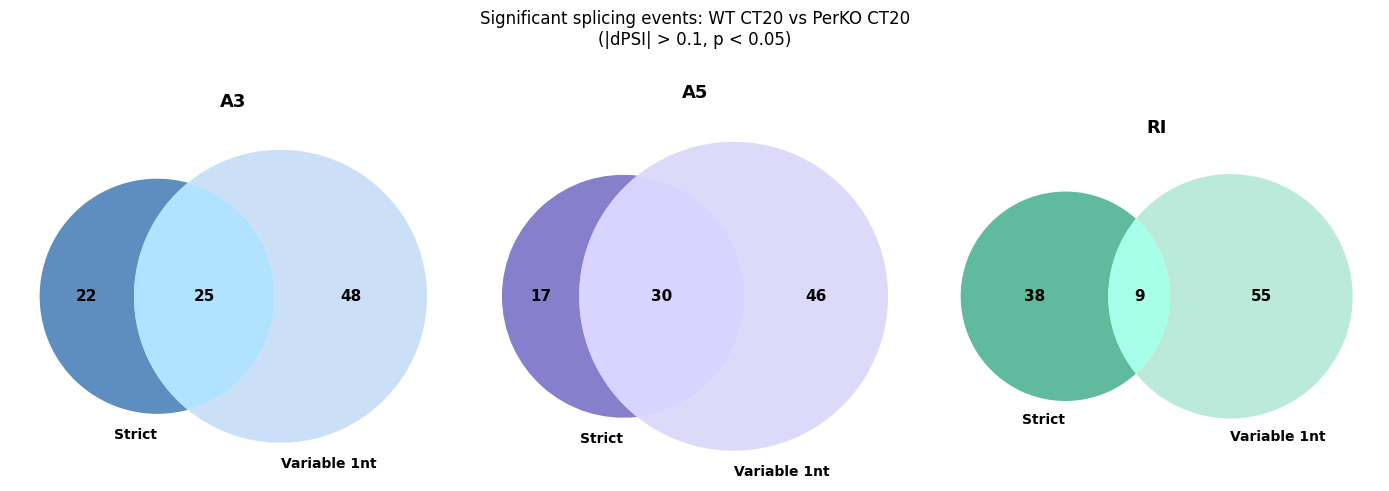

Saved!


In [75]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = {
    "A3": {"left": "#185FA5", "right": "#B5D4F4"},
    "A5": {"left": "#534AB7", "right": "#CECBF6"},
    "RI": {"left": "#1D9E75", "right": "#9FE1CB"}
}

for i, event in enumerate(EVENT_TYPES):
    pop = sig_events[event]

    n_strict_only = len(pop["strict"]) - len(pop["shared"])
    n_shared      = len(pop["shared"])
    n_var_only    = len(pop["var_only"])

    ax = axes[i]
    v = venn2(
        subsets=(n_strict_only, n_var_only, n_shared),
        set_labels=("Strict", "Variable 1nt"),
        ax=ax,
        set_colors=(colors[event]["left"], colors[event]["right"]),
        alpha=0.7,
    )

    # style the labels
    for text in v.set_labels:
        if text:
            text.set_fontsize(10)
            text.set_fontweight("bold")
    for text in v.subset_labels:
        if text:
            text.set_fontsize(11)
            text.set_fontweight("bold")

    ax.set_title(event, fontsize=13, fontweight="bold", pad=10)

plt.suptitle(
    "Significant splicing events: WT CT20 vs PerKO CT20\n(|dPSI| > 0.1, p < 0.05)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("../../figures/plots/venn_sig_events_CT20_PerKO.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

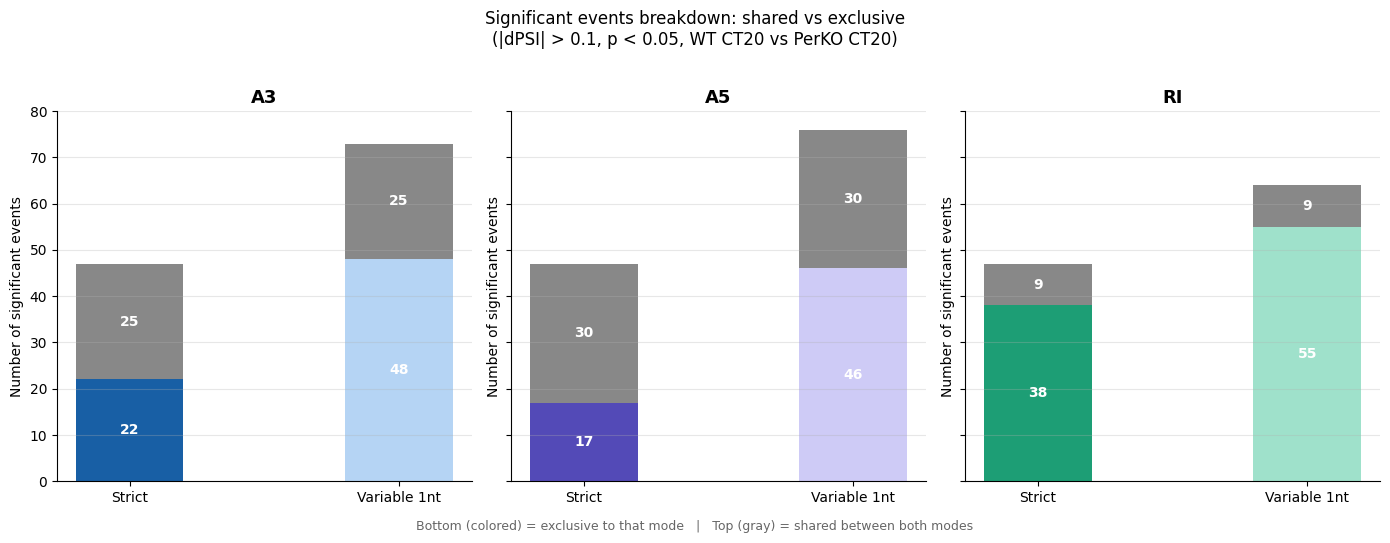

Saved!


In [76]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

colors_shared   = "#888888"
colors_exclusive = {
    "A3": {"strict": "#185FA5", "var1": "#B5D4F4"},
    "A5": {"strict": "#534AB7", "var1": "#CECBF6"},
    "RI": {"strict": "#1D9E75", "var1": "#9FE1CB"}
}

for i, event in enumerate(EVENT_TYPES):
    pop = sig_events[event]

    n_strict_only = len(pop["strict"]) - len(pop["shared"])
    n_shared      = len(pop["shared"])
    n_var_only    = len(pop["var_only"])

    ax = axes[i]

    # strict bar
    ax.bar(0, n_strict_only, color=colors_exclusive[event]["strict"],
           label="exclusive", width=0.4)
    ax.bar(0, n_shared, bottom=n_strict_only, color=colors_shared,
           label="shared", width=0.4)

    # variable bar
    ax.bar(1, n_var_only, color=colors_exclusive[event]["var1"],
           label="exclusive", width=0.4)
    ax.bar(1, n_shared, bottom=n_var_only, color=colors_shared,
           width=0.4)

    # count labels
    ax.text(0, n_strict_only / 2, str(n_strict_only),
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    ax.text(0, n_strict_only + n_shared / 2, str(n_shared),
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    ax.text(1, n_var_only / 2, str(n_var_only),
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    ax.text(1, n_var_only + n_shared / 2, str(n_shared),
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Strict", "Variable 1nt"], fontsize=10)
    ax.set_title(event, fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of significant events")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 80)
    ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70, 80])

# shared legend once
from matplotlib.patches import Patch

fig.text(0.5, -0.02,
         "Bottom (colored) = exclusive to that mode   |   Top (gray) = shared between both modes",
         ha="center", fontsize=9, color="#666666")
plt.suptitle(
    "Significant events breakdown: shared vs exclusive\n(|dPSI| > 0.1, p < 0.05, WT CT20 vs PerKO CT20)",
    fontsize=12, y=1.02
)

plt.tight_layout()
plt.savefig("../../figures/plots/barplot_sig_events_breakdown.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## Step 5 — delta PSI table (one CT20 sample)

Per Khushi: build a per-event table for a single WT CT20 sample, showing PSI in
each mode and the delta. We first pick which CT20 sample (KM4, KM5, KM6) has the
most usable data (fewest NaN among shared events), then build the table on it.

Columns: event_id | PSI_strict | PSI_variable | delta PSI

In [77]:
# Decide which CT20 sample to use: the one with the fewest NaN across all shared events
ct20_samples = CONDITIONS["CT20"]   # KM4, KM5, KM6

nan_counts = {km: 0 for km in ct20_samples}
total_counts = {km: 0 for km in ct20_samples}

for event in EVENT_TYPES:
    strict_shared = dpsi_data[event]["strict"]
    var1_shared   = dpsi_data[event]["var1"]
    for km in ct20_samples:
        # count rows where either mode is NaN for this sample
        either_nan = strict_shared[km].isna() | var1_shared[km].isna()
        nan_counts[km]   += int(either_nan.sum())
        total_counts[km] += len(either_nan)

print("NaN counts per CT20 sample (lower is better):")
for km in ct20_samples:
    pct = 100 * nan_counts[km] / total_counts[km]
    print(f"  {km}: {nan_counts[km]} NaN out of {total_counts[km]} ({pct:.1f}%)")

best_sample = min(ct20_samples, key=lambda km: nan_counts[km])
print(f"\nUsing {best_sample} (fewest NaN)")

NaN counts per CT20 sample (lower is better):
  KM4: 7149 NaN out of 26107 (27.4%)
  KM5: 7633 NaN out of 26107 (29.2%)
  KM6: 7779 NaN out of 26107 (29.8%)

Using KM4 (fewest NaN)


In [78]:
# Build the delta PSI table for the chosen CT20 sample, all event types combined
km = best_sample
table_rows = []

for event in EVENT_TYPES:
    strict_shared = dpsi_data[event]["strict"]
    var1_shared   = dpsi_data[event]["var1"]

    # Merge on event ID to handle duplicates safely
    strict_col = strict_shared[[km]].rename(columns={km: "PSI_strict"})
    var1_col   = var1_shared[[km]].rename(columns={km: "PSI_variable"})

    merged = strict_col.join(var1_col, how="inner")
    merged = merged.dropna()
    merged = merged[(merged["PSI_strict"] > 0) & (merged["PSI_strict"] < 1)]
    merged["delta_PSI"] = (merged["PSI_strict"] - merged["PSI_variable"]).abs()
    merged["event_type"] = event

    for eid, row in merged.iterrows():
        table_rows.append({
            "event_type":   event,
            "event_id":     eid,
            "PSI_strict":   round(row["PSI_strict"], 3),
            "PSI_variable": round(row["PSI_variable"], 3),
            "delta_PSI":    round(row["delta_PSI"], 3),
        })

df_dpsi = pd.DataFrame(table_rows).sort_values("delta_PSI", ascending=False).reset_index(drop=True)
print(f"Total shared, expressed events for {km}: {len(df_dpsi)}")
print(f"Events with delta PSI > 0.1: {(df_dpsi['delta_PSI'] > 0.1).sum()}")

display(style_table(df_dpsi.head(20),
                    f"Top 20 events by delta PSI (CT20 sample {km})"))

df_dpsi.to_csv(f"{BASE}/ioe_diff/dpsi_table_{km}.csv", index=False)
print(f"Full table saved -> {BASE}/ioe_diff/dpsi_table_{km}.csv")

export_table_png(df_dpsi.head(20),
                 "../../figures/plots/table_dpsi_top20.png",
                 title=f"Top 20 events by delta PSI (CT20 {km})",
                 figsize=(16, 9))


# Prepare a display-friendly version
df_display = df_dpsi.head(20).copy()
df_display["gene_id"] = df_display["event_id"].apply(lambda x: x.split(";")[0])
df_display["coordinates"] = df_display["event_id"].apply(lambda x: x.split(";")[1])
df_display = df_display[["event_type", "gene_id", "coordinates", "PSI_strict", "PSI_variable", "delta_PSI"]]

#display(style_table(df_display,
#                    f"Top 20 events by delta PSI (CT20 sample {km})"))

export_table_png(df_display,
                 "../../figures/plots/table_dpsi_top20.png",
                 title=f"Top 20 events by delta PSI (CT20 {km})",
                 figsize=(18, 9))

Total shared, expressed events for KM4: 10308
Events with delta PSI > 0.1: 1482


event_type,event_id,PSI_strict,PSI_variable,delta_PSI
A3,ENSMUSG00000015083;A3:2:25389517:25389127:-,0.977000,0.025000,0.952000
A5,ENSMUSG00000045128;A5:8:71348244:71348560:-,0.969000,0.025000,0.943000
A5,ENSMUSG00000022868;A5:16:22713629:22713185:+,0.999000,0.068000,0.932000
A3,ENSMUSG00000045128;A3:8:71348353:71348151:-,0.919000,0.009000,0.910000
A5,ENSMUSG00000056035;A5:5:145795531:145797122:-,0.957000,0.053000,0.905000
RI,ENSMUSG00000029860;RI:6:42327053-42327191:+,0.929000,0.031000,0.897000
A3,ENSMUSG00000053332;A3:1:160863322:160864390:+,1.000000,0.103000,0.897000
A5,ENSMUSG00000053332;A5:1:160865842:160865607:+,1.000000,0.109000,0.891000
A3,ENSMUSG00000053332;A3:1:160863553:160863778:+,0.987000,0.108000,0.879000
A3,ENSMUSG00000053332;A3:1:160863322:160863553:+,0.983000,0.107000,0.876000


Full table saved -> /Users/gricey/Desktop/Internship/data/ioe_diff/dpsi_table_KM4.csv
Saved -> ../../figures/plots/table_dpsi_top20.png
Saved -> ../../figures/plots/table_dpsi_top20.png


## Step 6 — Pick a high delta PSI example for IGV

The single event with the largest delta PSI is the clearest case to inspect visually:
strict and variable assign very different inclusion levels to the same splice event.
We print its coordinates so it can be located directly in IGV.

In [79]:
top_event = df_dpsi.iloc[0]
print("Best candidate for IGV (largest delta PSI):")
print(f"  Event type:   {top_event['event_type']}")
print(f"  Event ID:     {top_event['event_id']}")
print(f"  PSI strict:   {top_event['PSI_strict']}")
print(f"  PSI variable: {top_event['PSI_variable']}")
print(f"  delta PSI:    {top_event['delta_PSI']}")
print()

# Parse coordinates for IGV navigation
eid = top_event["event_id"]
gene = eid.split(";")[0]
rest = eid.split(";")[1]
parts = rest.split(":")
chrom = parts[1]
strand = parts[-1]
coords = parts[2:-1]
print(f"  Gene:   {gene}")
print(f"  Chrom:  {chrom}  Strand: {strand}")
print(f"  Coords: {coords}")
print(f"  IGV search: {chrom}:{coords}")

Best candidate for IGV (largest delta PSI):
  Event type:   A3
  Event ID:     ENSMUSG00000015083;A3:2:25389517:25389127:-
  PSI strict:   0.977
  PSI variable: 0.025
  delta PSI:    0.952

  Gene:   ENSMUSG00000015083
  Chrom:  2  Strand: -
  Coords: ['25389517', '25389127']
  IGV search: 2:['25389517', '25389127']


## PSI per condition: shared vs variable-only genes

For each condition (CT8, CT20, PerKO), compare the PSI distributions of events
from shared genes (detected in both modes) vs variable-only genes (missed by strict).
This shows whether the newly detected events have comparable splicing levels
or are systematically weaker.

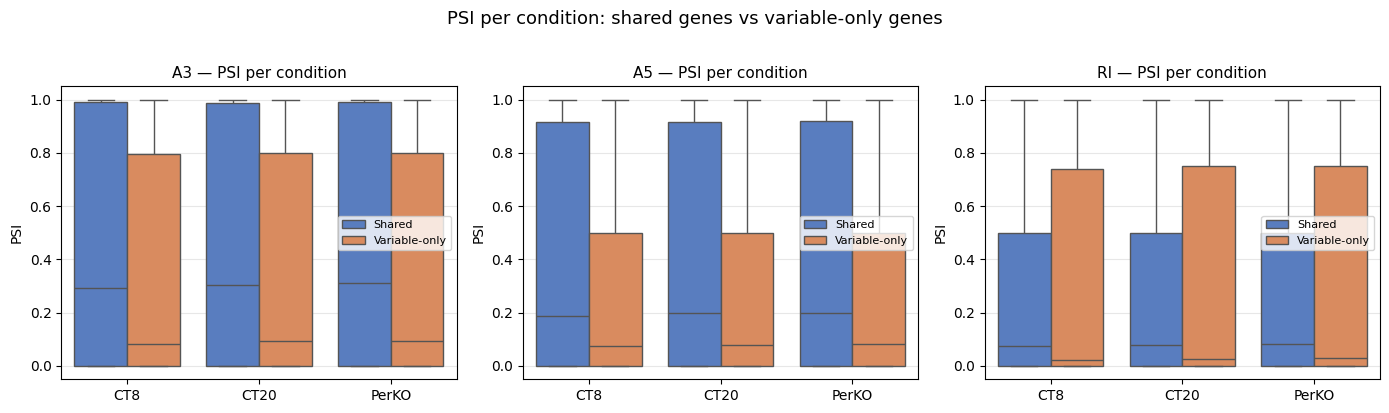

Saved!


In [80]:
# --- Boxplot: PSI per condition for shared vs variable-only genes ---

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
muted = sns.color_palette("muted", 3)

for i, event in enumerate(EVENT_TYPES):
    strict_df = psi[("strict", event)]
    var1_df   = psi[("var1",   event)]

    strict_genes  = set(idx.split(";")[0] for idx in strict_df.index
                        if idx.startswith("ENSMUSG"))
    var1_genes    = set(idx.split(";")[0] for idx in var1_df.index
                        if idx.startswith("ENSMUSG"))
    shared_genes  = strict_genes & var1_genes
    varonly_genes = var1_genes - strict_genes

    rows = []
    for cond, samples in CONDITIONS.items():
        shared_psi = var1_df[
            var1_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
            .isin(shared_genes)
        ][samples].values.flatten()

        varonly_psi = var1_df[
            var1_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
            .isin(varonly_genes)
        ][samples].values.flatten()

        for v in shared_psi[~np.isnan(shared_psi)]:
            rows.append({"Condition": cond, "Population": "Shared", "PSI": v})
        for v in varonly_psi[~np.isnan(varonly_psi)]:
            rows.append({"Condition": cond, "Population": "Variable-only", "PSI": v})

    df_plot = pd.DataFrame(rows)

    ax = axes[i]
    sns.boxplot(
        data=df_plot, x="Condition", y="PSI", hue="Population",
        palette={"Shared": muted[0], "Variable-only": muted[1]},
        showfliers=False, ax=ax
    )
    ax.set_title(f"{event} — PSI per condition", fontsize=11)
    ax.set_ylabel("PSI")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("PSI per condition: shared genes vs variable-only genes",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/boxplot_psi_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [81]:
# Stats: proportion of shared events with large dPSI
thresholds = [0.05, 0.1, 0.2, 0.5, 0.8]

rows_stats = []
for event in EVENT_TYPES:
    event_df = df_dpsi[df_dpsi["event_type"] == event]
    n_total = len(event_df)
    row = {"Event": event, "Total events (0<PSI<1)": n_total}
    for t in thresholds:
        n_above = (event_df["delta_PSI"] > t).sum()
        pct = 100 * n_above / n_total if n_total > 0 else 0
        row[f"|dPSI| > {t}"] = f"{n_above} ({pct:.1f}%)"
    rows_stats.append(row)

df_stats = pd.DataFrame(rows_stats)
display(style_table(df_stats, f"dPSI magnitude breakdown (CT20 {km})"))
export_table_png(df_stats,
                 "../../figures/plots/table_dpsi_stats.png",
                 title=f"dPSI magnitude breakdown (CT20 {km})",
                 figsize=(18, 3))

Event,Total events (0<PSI<1),|dPSI| > 0.05,|dPSI| > 0.1,|dPSI| > 0.2,|dPSI| > 0.5,|dPSI| > 0.8
A3,3990,579 (14.5%),456 (11.4%),305 (7.6%),73 (1.8%),12 (0.3%)
A5,3511,586 (16.7%),445 (12.7%),314 (8.9%),110 (3.1%),13 (0.4%)
RI,2807,776 (27.6%),581 (20.7%),361 (12.9%),62 (2.2%),7 (0.2%)


Saved -> ../../figures/plots/table_dpsi_stats.png


In [82]:
# Gene-level: how many unique genes have at least one event above each dPSI threshold
rows_genes = []
for event in EVENT_TYPES:
    event_df = df_dpsi[df_dpsi["event_type"] == event].copy()
    event_df["gene_id"] = event_df["event_id"].apply(lambda x: x.split(";")[0])
    
    n_total_genes = event_df["gene_id"].nunique()
    row = {"Event": event, "Total genes (0<PSI<1)": n_total_genes}
    
    for t in thresholds:
        genes_above = event_df[event_df["delta_PSI"] > t]["gene_id"].nunique()
        pct = 100 * genes_above / n_total_genes if n_total_genes > 0 else 0
        row[f"|dPSI| > {t}"] = f"{genes_above} ({pct:.1f}%)"
    
    rows_genes.append(row)

df_stats_genes = pd.DataFrame(rows_genes)
display(style_table(df_stats_genes, f"dPSI magnitude breakdown at gene level (CT20 {km})"))
export_table_png(df_stats_genes,
                 "../../figures/plots/table_dpsi_stats_genes.png",
                 title=f"dPSI magnitude breakdown at gene level (CT20 {km})",
                 figsize=(18, 3))

Event,Total genes (0<PSI<1),|dPSI| > 0.05,|dPSI| > 0.1,|dPSI| > 0.2,|dPSI| > 0.5,|dPSI| > 0.8
A3,2804,447 (15.9%),361 (12.9%),244 (8.7%),62 (2.2%),10 (0.4%)
A5,2468,440 (17.8%),348 (14.1%),248 (10.0%),84 (3.4%),7 (0.3%)
RI,1768,412 (23.3%),315 (17.8%),211 (11.9%),43 (2.4%),7 (0.4%)


Saved -> ../../figures/plots/table_dpsi_stats_genes.png


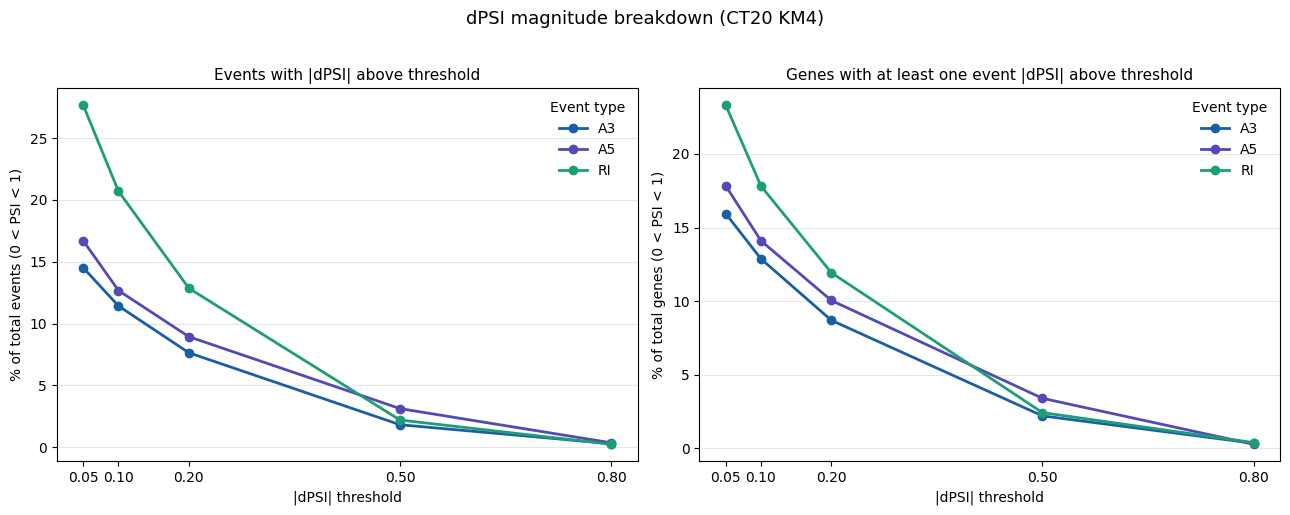

Saved!


In [83]:
thresholds_num = [0.05, 0.1, 0.2, 0.5, 0.8]

event_colors_main = {
    "A3": "#185FA5",
    "A5": "#534AB7",
    "RI": "#1D9E75",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: event level ---
ax = axes[0]
for event in EVENT_TYPES:
    event_df = df_dpsi[df_dpsi["event_type"] == event]
    n_total = len(event_df)
    pcts = [100 * (event_df["delta_PSI"] > t).sum() / n_total for t in thresholds_num]
    ax.plot(thresholds_num, pcts, marker="o", label=event,
            color=event_colors_main[event], linewidth=2)

ax.set_title("Events with |dPSI| above threshold", fontsize=11)
ax.set_xlabel("|dPSI| threshold")
ax.set_ylabel("% of total events (0 < PSI < 1)")
ax.legend(title="Event type", frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.set_xticks(thresholds_num)

# --- Right: gene level ---
ax = axes[1]
for event in EVENT_TYPES:
    event_df = df_dpsi[df_dpsi["event_type"] == event].copy()
    event_df["gene_id"] = event_df["event_id"].apply(lambda x: x.split(";")[0])
    n_total_genes = event_df["gene_id"].nunique()
    pcts = []
    for t in thresholds_num:
        genes_above = event_df[event_df["delta_PSI"] > t]["gene_id"].nunique()
        pcts.append(100 * genes_above / n_total_genes if n_total_genes > 0 else 0)
    ax.plot(thresholds_num, pcts, marker="o", label=event,
            color=event_colors_main[event], linewidth=2)

ax.set_title("Genes with at least one event |dPSI| above threshold", fontsize=11)
ax.set_xlabel("|dPSI| threshold")
ax.set_ylabel("% of total genes (0 < PSI < 1)")
ax.legend(title="Event type", frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.set_xticks(thresholds_num)

plt.suptitle(f"dPSI magnitude breakdown (CT20 {km})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/lineplot_dpsi_magnitude.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")